In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv(r"/content/all_csv_5_percent_all_attacks (1).xls")

In [5]:
import numpy as np
from sklearn.preprocessing import LabelEncoder
# 2. Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# 3. Remove timestamp/date columns
for col in df.columns:
    if "time" in col.lower() or "timestamp" in col.lower():
        df.drop(columns=[col], inplace=True)

# 4. Remove known duplicate CICIDS column if present
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)

# 5. Set target column
target_col = "Label"

# 6. Remove rows where label is missing
df = df[df[target_col].notna()]

# 7. Clean label values
df[target_col] = df[target_col].astype(str).str.strip()

# 8. Remove accidental repeated header rows
df = df[df[target_col].str.lower() != "label"]

# 9. Keep only required classes
selected_classes = [
    "Benign",
    "DDOS attack-HOIC",
    "DoS attacks-Hulk",
    "Bot",
    "FTP-BruteForce",
    "SSH-Bruteforce",
    "Infilteration",
    "DoS attacks-SlowHTTPTest",
    "DoS attacks-GoldenEye",
    "DoS attacks-Slowloris",
    "DDOS attack-LOIC-UDP",
    "Brute Force -Web",
    "Brute Force -XSS",
    "SQL Injection"
]
df = df[df[target_col].isin(selected_classes)]

# 10. Replace infinity values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# 11. Convert feature columns to numeric
for col in df.columns:
    if col != target_col:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 12. Remove null values
df.dropna(inplace=True)

# 13. Remove duplicate rows
df.drop_duplicates(inplace=True)

# 14. Encode labels
label_encoder = LabelEncoder()
df["Encoded_Label"] = label_encoder.fit_transform(df[target_col])

# 15. Separate features and target
X = df.drop(columns=[target_col, "Encoded_Label"])
y = df["Encoded_Label"]

# 16. Keep only numeric features
X = X.select_dtypes(include=[np.number])

# 17. Remove low-information sparse rows
non_zero_mask = (X != 0).sum(axis=1) > 5
X = X[non_zero_mask]
y = y[non_zero_mask]

# 18. Final cleaned dataframe
df_cleaned = X.copy()
df_cleaned["Encoded_Label"] = y.values

# Final checks
print("Final Shape:", df_cleaned.shape)
print("\nClass Encoding:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

print("\nClass Distribution:")
print(df_cleaned["Encoded_Label"].value_counts())

print("\nNull Values:", df_cleaned.isnull().sum().sum())
print("Infinity Values:", np.isinf(df_cleaned.select_dtypes(include=[np.number])).sum().sum())
print("Duplicate Rows:", df_cleaned.duplicated().sum())

Final Shape: (63481, 79)

Class Encoding:
{'Benign': np.int64(0), 'Bot': np.int64(1), 'Brute Force -Web': np.int64(2), 'Brute Force -XSS': np.int64(3), 'DDOS attack-HOIC': np.int64(4), 'DDOS attack-LOIC-UDP': np.int64(5), 'DoS attacks-GoldenEye': np.int64(6), 'DoS attacks-Hulk': np.int64(7), 'DoS attacks-SlowHTTPTest': np.int64(8), 'DoS attacks-Slowloris': np.int64(9), 'FTP-BruteForce': np.int64(10), 'Infilteration': np.int64(11), 'SQL Injection': np.int64(12), 'SSH-Bruteforce': np.int64(13)}

Class Distribution:
Encoded_Label
0     51689
1      8189
4      1652
7      1131
11      399
13      237
6       105
9        28
10       24
8        20
5         4
3         1
2         1
12        1
Name: count, dtype: int64

Null Values: 0
Infinity Values: 0
Duplicate Rows: 0


In [6]:
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import torch.optim as optim

import matplotlib.pyplot as plt
from torchvision import transforms

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [8]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

target_col = "Label"
label_encoder = LabelEncoder()
df["Encoded_Label"] = label_encoder.fit_transform(df[target_col])

print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

{'Benign': np.int64(0), 'Bot': np.int64(1), 'Brute Force -Web': np.int64(2), 'Brute Force -XSS': np.int64(3), 'DDOS attack-HOIC': np.int64(4), 'DDOS attack-LOIC-UDP': np.int64(5), 'DoS attacks-GoldenEye': np.int64(6), 'DoS attacks-Hulk': np.int64(7), 'DoS attacks-SlowHTTPTest': np.int64(8), 'DoS attacks-Slowloris': np.int64(9), 'FTP-BruteForce': np.int64(10), 'Infilteration': np.int64(11), 'SQL Injection': np.int64(12), 'SSH-Bruteforce': np.int64(13)}


In [9]:
target_col = "Encoded_Label"

df_selected = X.copy()
df_selected[target_col] = y

print(df_selected.shape)
print(df_selected[target_col].value_counts())

(63481, 79)
Encoded_Label
0     51689
1      8189
4      1652
7      1131
11      399
13      237
6       105
9        28
10       24
8        20
5         4
3         1
2         1
12        1
Name: count, dtype: int64


In [10]:
X_gan = df_selected.drop(columns=[target_col])
y_gan = df_selected[target_col].astype(int)

In [11]:
from sklearn.preprocessing import StandardScaler

scaler_gan = StandardScaler()

X_gan_scaled = scaler_gan.fit_transform(X_gan)

scaled_df = pd.DataFrame(
    X_gan_scaled,
    columns=X_gan.columns
)

In [12]:
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

#X_tensor = torch.tensor(X_gan_scaled, dtype=torch.float32)
#y_tensor = torch.tensor(y_gan.values, dtype=torch.long)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X_tensor = torch.tensor(X_gan_scaled, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_gan.values, dtype=torch.long).to(device)

dataset = TensorDataset(X_tensor, y_tensor)

loader = DataLoader(
    dataset,
    batch_size=256,
    shuffle=True
)

In [13]:
input_dim = X_tensor.shape[1]

num_classes = len(np.unique(y_gan))

latent_dim = 64

print("Input Features:", input_dim)
print("Classes:", num_classes)

Input Features: 78
Classes: 14


In [14]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")
print("Torch CUDA version:", torch.version.cuda)

CUDA available: True
GPU: Tesla T4
Torch CUDA version: 12.8


In [15]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 56.3 MB/s eta 0:00:00


In [16]:
from ctgan import CTGAN
import pandas as pd

# Create CTGAN dataframe
df_ctgan = df_cleaned.copy()

# Target column
target_col = "Encoded_Label"

# Convert all column names to normal string
df_ctgan.columns = df_ctgan.columns.astype(str)

# Convert dataframe string columns to object
for col in df_ctgan.columns:
    if str(df_ctgan[col].dtype) == "string":
        df_ctgan[col] = df_ctgan[col].astype(object)

# CTGAN categorical columns
df_ctgan[target_col] = df_ctgan[target_col].astype(str)

categorical_columns = [target_col]

print(df_ctgan.dtypes)

# Initialize CTGAN
ctgan = CTGAN(
    epochs=50,
    batch_size=1000,
    verbose=True,
    enable_gpu=True
)

print("CTGAN Device:", ctgan._device)

# Train
ctgan.fit(df_ctgan, categorical_columns)

print("CTGAN Training Completed")

Dst Port           int64
Protocol           int64
Flow Duration      int64
Tot Fwd Pkts       int64
Tot Bwd Pkts       int64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Encoded_Label     object
Length: 79, dtype: object
CTGAN Device: cuda


Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/50 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass
Gen. (-00.67) | Discrim. (-01.50): 100%|██████████| 50/50 [05:13<00:00,  6.27s/it]

CTGAN Training Completed


In [17]:
synthetic_df = ctgan.sample(len(df_ctgan))

print(synthetic_df.shape)
print(synthetic_df.head())

(63481, 79)
   Dst Port  Protocol  Flow Duration  Tot Fwd Pkts  Tot Bwd Pkts  \
0      -466         6         921300             5             8   
1     56915        17        -256536            14            10   
2     48908        17        -166528            22            -6   
3      8027         6          49235            -1             1   
4       -26         6      111797145            18             0   

   TotLen Fwd Pkts  TotLen Bwd Pkts  Fwd Pkt Len Max  Fwd Pkt Len Min  \
0              624     -9607.608794              331                0   
1             -599      7362.231456               14                0   
2              -58      6605.867561               60                0   
3              763     -3405.623873              332                0   
4             -190     -1601.430804                1                0   

   Fwd Pkt Len Mean  ...  Fwd Seg Size Min    Active Mean    Active Std  \
0          1.815594  ...                20  -20328.094101  11215.

In [18]:
print("Real label distribution:")
print(df_ctgan["Encoded_Label"].value_counts(normalize=True))

print("\nSynthetic label distribution:")
print(synthetic_df["Encoded_Label"].value_counts(normalize=True))

Real label distribution:
Encoded_Label
0     0.814244
1     0.128999
4     0.026024
7     0.017816
11    0.006285
13    0.003733
6     0.001654
9     0.000441
10    0.000378
8     0.000315
5     0.000063
3     0.000016
2     0.000016
12    0.000016
Name: proportion, dtype: float64

Synthetic label distribution:
Encoded_Label
0     0.169011
1     0.140672
4     0.117437
7     0.110521
11    0.094879
13    0.086703
6     0.072447
9     0.052850
10    0.049385
8     0.048629
5     0.024826
3     0.011641
12    0.010948
2     0.010050
Name: proportion, dtype: float64


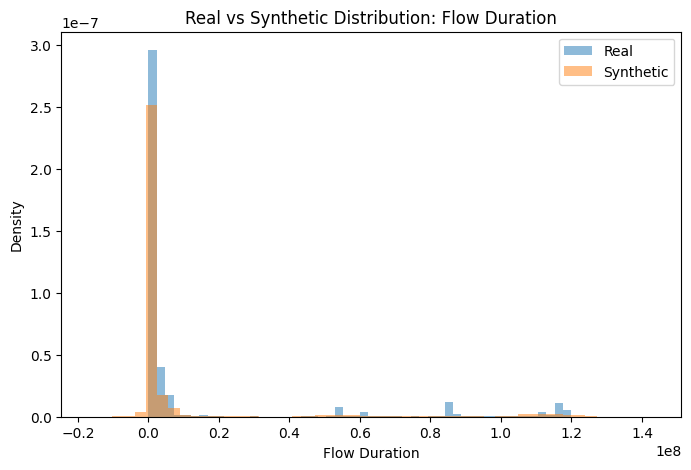

In [19]:
import matplotlib.pyplot as plt

feature = "Flow Duration"   # change feature name

plt.figure(figsize=(8, 5))
plt.hist(df_ctgan[feature], bins=50, alpha=0.5, label="Real", density=True)
plt.hist(synthetic_df[feature], bins=50, alpha=0.5, label="Synthetic", density=True)
plt.title(f"Real vs Synthetic Distribution: {feature}")
plt.xlabel(feature)
plt.ylabel("Density")
plt.legend()
plt.show()

In [20]:
numeric_cols = df_ctgan.select_dtypes(include=["int64", "float64"]).columns

quality_df = pd.DataFrame({
    "Real_Mean": df_ctgan[numeric_cols].mean(),
    "Synthetic_Mean": synthetic_df[numeric_cols].mean(),
    "Real_Std": df_ctgan[numeric_cols].std(),
    "Synthetic_Std": synthetic_df[numeric_cols].std()
})

quality_df["Mean_Difference"] = abs(
    quality_df["Real_Mean"] - quality_df["Synthetic_Mean"]
)

quality_df.head(20)

,Real_Mean,Synthetic_Mean,Real_Std,Synthetic_Std,Mean_Difference
Dst Port,9.625889e+03,3.963476e+03,1.786256e+04,1.142507e+04,5.662413e+03
Protocol,8.293521e+00,6.710654e+00,4.622590e+00,2.733072e+00,1.582867e+00
Flow Duration,1.326871e+07,8.468539e+06,3.186175e+07,2.625764e+07,4.800171e+06
Tot Fwd Pkts,1.379788e+01,2.020787e+01,9.352158e+02,3.836338e+01,6.409997e+00
Tot Bwd Pkts,9.936753e+00,2.277012e+00,4.122463e+02,1.685465e+01,7.659741e+00
TotLen Fwd Pkts,6.867489e+02,4.173336e+02,2.985462e+04,1.377546e+03,2.694153e+02
TotLen Bwd Pkts,9.015877e+03,-4.168532e+02,5.991415e+05,9.281513e+03,9.432730e+03
Fwd Pkt Len Max,2.572463e+02,1.832826e+02,3.006773e+02,2.625184e+02,7.396371e+01
Fwd Pkt Len Min,9.243569e+00,3.152928e+00,2.208386e+01,1.194725e+01,6.090641e+00
Fwd Pkt Len Mean,6.423573e+01,5.233983e+01,6.069728e+01,6.521258e+01,1.189590e+01


In [22]:
import sys
sys.path.append(r"C:\Users\Aditya\Desktop\VECC Intern\AI NIDS Project\tabsyndex")

In [28]:
pip install dython==0.6.8

In [31]:
import scipy
import numpy as np

# Patch old scikit-plot dependency
scipy.interp = np.interp

from tabsyndex import *

In [41]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import copy
import math
import sklearn.metrics as sk
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import Lasso, Ridge, ElasticNet, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
import scipy.stats as ss
from dython.nominal import compute_associations, numerical_encoding

In [43]:
# Read file
with open("/content/tabsyndex.py", "r") as f:
    code = f.read()

# Remove old argument
code = code.replace(", theil_u=True", "")

# Write back
with open("/content/tabsyndex.py", "w") as f:
    f.write(code)

print("Patched successfully")

Patched successfully


In [45]:
import sys

if "tabsyndex" in sys.modules:
    del sys.modules["tabsyndex"]

In [46]:
from tabsyndex import *

In [47]:
!grep -n "theil_u" /content/tabsyndex.py

In [49]:
with open("/content/tabsyndex.py", "r") as f:
    code = f.read()

code = code.replace(
    "mean_squared_error(real_corr, fake_corr, squared=False)",
    "mean_squared_error(real_corr, fake_corr) ** 0.5"
)

code = code.replace(
    "mean_squared_error(real_data, fake_data, squared=False)",
    "mean_squared_error(real_data, fake_data) ** 0.5"
)

with open("/content/tabsyndex.py", "w") as f:
    f.write(code)

print("Patched squared=False issue")

Patched squared=False issue


In [50]:
import sys

if "tabsyndex" in sys.modules:
    del sys.modules["tabsyndex"]

In [52]:
with open("/content/tabsyndex.py", "r") as f:
    code = f.read()

# Remove all sklearn squared=False usages
code = code.replace("squared=False", "")

with open("/content/tabsyndex.py", "w") as f:
    f.write(code)

print("Removed all squared=False")

Removed all squared=False


In [53]:
import sys

if "tabsyndex" in sys.modules:
    del sys.modules["tabsyndex"]

In [55]:
with open("/content/tabsyndex.py", "r") as f:
    code = f.read()

# Replace old pandas append usage
code = code.replace(".append(", "._append(")

with open("/content/tabsyndex.py", "w") as f:
    f.write(code)

print("Patched pandas append issue")

Patched pandas append issue


In [56]:
import sys

if "tabsyndex" in sys.modules:
    del sys.modules["tabsyndex"]

In [57]:
import scipy
import numpy as np
scipy.interp = np.interp

from tabsyndex import *

real_data = df_ctgan.copy()
synthetic_data = synthetic_df.copy()

# Force every column to numeric
for col in real_data.columns:
    real_data[col] = pd.to_numeric(real_data[col], errors="coerce")

for col in synthetic_data.columns:
    synthetic_data[col] = pd.to_numeric(synthetic_data[col], errors="coerce")

# Remove NaN/inf
real_data.replace([np.inf, -np.inf], np.nan, inplace=True)
synthetic_data.replace([np.inf, -np.inf], np.nan, inplace=True)

real_data.dropna(inplace=True)
synthetic_data.dropna(inplace=True)

# Make sure both have same columns
synthetic_data = synthetic_data[real_data.columns]

# IMPORTANT: use no categorical columns here
score = tabsyndex(
    real_data,
    synthetic_data,
    cat_cols=["Encoded_Label"]
)

print("TabSynDex Score:", score)

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: divide by zero encountered in log
  result = func(self.values, **kwargs)


TabSynDex Score: {'score': np.float64(0.2717751105974164), 'basic_score': np.float64(0.5122211918159673), 'corr_score': 0.0, 'ml_score': np.float64(0.2660432305819789), 'sup_score': np.float64(0.5806111305891358), 'pmse_score': 4.744903194456484e-131}
